In [1]:
from pathlib import Path

import prism

from imagematerials.eol import eol_preprocess
from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import (
    EndOfLife,
    GenericMaterials,
    GenericStocks,
    Maintenance,
    MaterialIntensities,
)
from imagematerials.preprocessing import get_preprocessing_data

In [2]:
scenario_list = {"base":("SSP2",["base"])}

In [3]:
scenario_base_path = Path("../data/raw") / 'circular_economy_scenarios'

# Define the complete timeline, including historic tail
# time_start = prep_data["stocks"].coords["Time"].min().values
time_start = 1960
complete_timeline = prism.Timeline(time_start, 2060, 1)
simulation_timeline = prism.Timeline(1970, 2060, 1)

all_output = {}

for scen_id, (climate_scen, circular_scen) in scenario_list.items():
    climate_policy_scenario_dir = Path("..", "data", "raw", "IMAGE_CircoMod", climate_scen)
    circular_economy_scenario_dirs = {
        scenario: scenario_base_path / scenario for scenario in circular_scen
    }

    bld_sector = get_preprocessing_data("buildings", Path("..", "data", "raw"), climate_policy_scenario_dir, circular_economy_scenario_dirs) 




    factory = ModelFactory(
    [bld_sector], complete_timeline
    ).add(GenericStocks, ["buildings"]
    ).add(MaterialIntensities, "buildings",
)
    model = factory.finish()

    import warnings
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model.simulate(simulation_timeline)

    print(f"Finished {scen_id}")

c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev\Lib\site-packages\xarray\core\indexing.py:1566: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev\Lib\site-packages\xarray\core\indexing.py:1566: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


implemented 'base' for Commercial Buildings
implemented 'base' for Residential Buildings
Finished base


In [4]:
bld_sector.prep_data.get("stocks").Type.values

array(['Appartment - Rural', 'Appartment - Urban', 'Detached - Rural',
       'Detached - Urban', 'High-rise - Rural', 'High-rise - Urban',
       'Semi-detached - Rural', 'Semi-detached - Urban', 'Office',
       'Retail+', 'Hotels+', 'Govt+'], dtype='<U21')

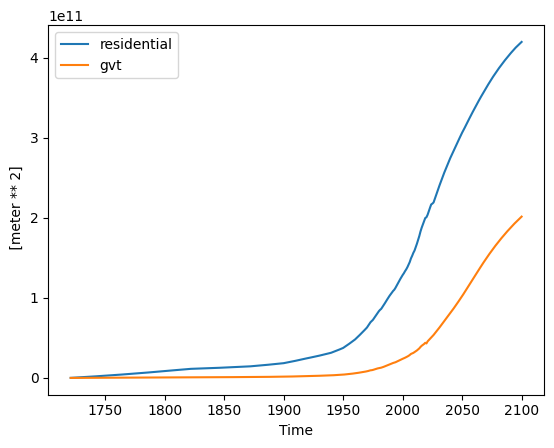

In [5]:
import matplotlib.pyplot as plt


bld_sector.prep_data.get("stocks").sel(Type = ['Appartment - Rural', 'Appartment - Urban', 'Detached - Rural',
       'Detached - Urban', 'High-rise - Rural', 'High-rise - Urban',
       'Semi-detached - Rural', 'Semi-detached - Urban']).sum(["Region", "Type"]).plot(label = 'residential')

bld_sector.prep_data.get("stocks").sel(Type = ['Office',
       'Retail+', 'Hotels+', 'Govt+']).sum(["Region", "Type"]).plot(label = 'gvt')
plt.legend()

In [6]:
model.buildings.keys()

dict_keys(['stocks', 'lifetimes', 'material_intensities', 'knowledge_graph', 'set_unit_flexible', 'outflow_by_cohort', 'inflow', 'stock_by_cohort', 'stock_by_cohort_materials', 'inflow_materials', 'outflow_by_cohort_materials'])

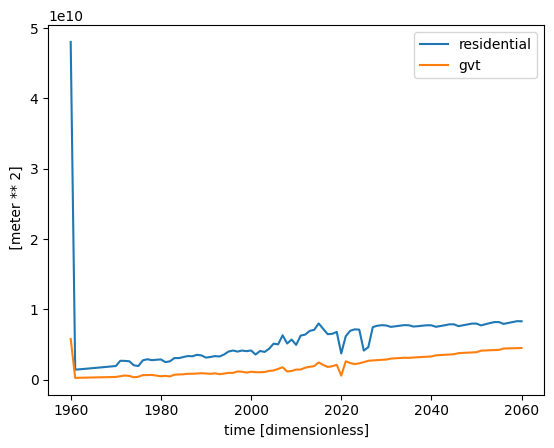

In [7]:
model.buildings.get("inflow").to_array().sel(Type = ['Appartment - Rural', 'Appartment - Urban', 'Detached - Rural',
       'Detached - Urban', 'High-rise - Rural', 'High-rise - Urban',
       'Semi-detached - Rural', 'Semi-detached - Urban']).sum(["Region", "Type"]).plot(label = 'residential')

model.buildings.get("inflow").to_array().sel(Type = ['Office',
       'Retail+', 'Hotels+', 'Govt+']).sum(["Region", "Type"]).plot(label = 'gvt')

plt.legend()

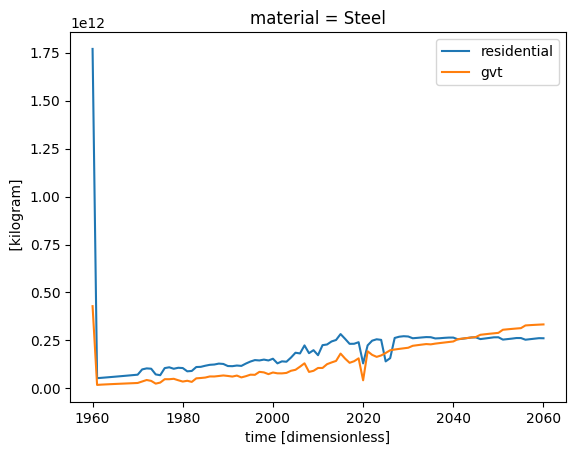

In [8]:
model.buildings.get("inflow_materials").to_array().sel(material = 'Steel', Type = ['Appartment - Rural', 'Appartment - Urban', 'Detached - Rural',
       'Detached - Urban', 'High-rise - Rural', 'High-rise - Urban',
       'Semi-detached - Rural', 'Semi-detached - Urban']).sum(["Region", "Type"]).plot(label = 'residential')

model.buildings.get("inflow_materials").to_array().sel(material = 'Steel', Type = ['Office',
       'Retail+', 'Hotels+', 'Govt+']).sum(["Region", "Type"]).plot(label = 'gvt')

plt.legend()